# Classical Monte Carlo benchmark for quantum CVA

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

from quantum_cva.mc_benchmark.benchmark_utils import (
    P0,
    build_survival_from_cds,
    simulate_S,
    discount_factors_on_grid,
    default_increments_on_grid,
    positive_exposure_matrix_from_samples,
    cva_from_continuous_blocks,
    grid_and_prob_matrix,
    build_p_target_from_samples,
    payoff_matrix_forward_call,
    cva_discrete_from_blocks
)

from quantum_cva.mc_benchmark.data_saving_utils import save_classical_tables

from quantum_cva.mc_benchmark.scaling_constants import extract_tables_and_scalings

In [2]:
# Root to data folder 
from pathlib import Path
import quantum_cva
import json

REPO_ROOT = Path(quantum_cva.__file__).resolve().parents[2]
OUT_DIR = REPO_ROOT / "data" / "classical_cva_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)

---

### CVA of a  *single underlying Equity-Forward*

Specifications of the estimation using classical Monte Carlo methods: 

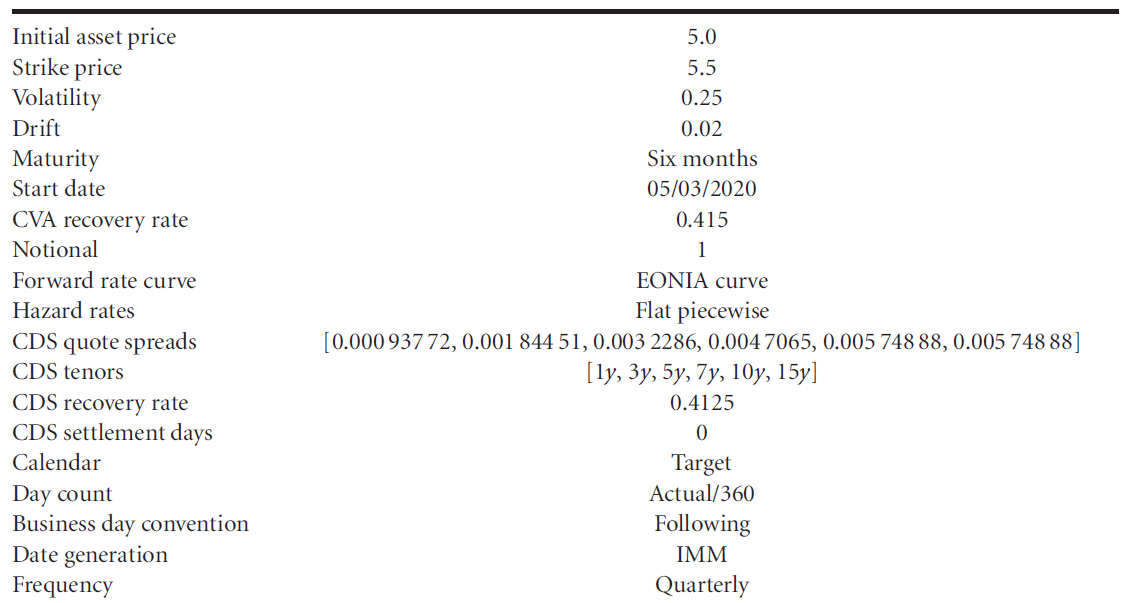

In [3]:
# =============================
# Simulation parameters
# =============================
S0 = 5.0
K = 5.5
sigma = 0.25
mu = 0.02
r = mu # approx flat curve equal to drift

N_paths = 10**5
M = 4
seed = 105
rng = np.random.default_rng(42)
Z = rng.standard_normal(size=(N_paths, M - 1))

R_cva = 0.415
R_cds = 0.4125
LGD = 1.0 - R_cva

T = 184/360
t = np.linspace(0.0, T, M)

rng = np.random.default_rng()

# Flat-curve discount function for CDS bootstrap
P0_flat = lambda u: P0(u, r)

# CDS specifications
cds_tenors_years = [1, 3, 5, 7, 10, 15]
cds_spreads = [
    0.00093772,
    0.00184451,
    0.0032286,
    0.0047065,
    0.00574888,
    0.00574888
]

Default probabilities are obtained by calibrating a piecewise-constant hazard rate function to market CDS par spreads. The bootstrapping procedure does not compute survival probabilities directly; instead, it determines the hazard rates from which survival and default probabilities are subsequently derived.

In the paper, the hazard rate is assumed to be constant between consecutive CDS maturities:
$$
\lambda(t) = \lambda_i \quad \text{for } t \in (T_{i-1}, T_i],
$$
where $\{T_i\}$ denote the CDS maturities. Given this (piecewise) specification, the survival probability admits the representation
$$
S(t) = \exp\!\left(-\int_0^t \lambda(s)\,ds\right)
= \exp\!\left(-\sum_{j=1}^{i-1} \lambda_j (T_j-T_{j-1}) - \lambda_i (t-T_{i-1})\right),
\qquad t \in (T_{i-1},T_i].
$$

For a CDS with maturity $T_i$ and market par spread $s_i$, the no-arbitrage condition requires the contract to have zero value at inception. This implies that the present value of the premium leg equals the present value of the protection leg:
$$
\mathrm{PV}_{\mathrm{premium}}(T_i;\lambda_1,\dots,\lambda_i)
=
\mathrm{PV}_{\mathrm{protection}}(T_i;\lambda_1,\dots,\lambda_i).
$$

Assuming quarterly payments with accrual fraction $\Delta t = 0.25$, the present value of the premium leg (without accrual on default) can be written as
$$
\mathrm{PV}_{\mathrm{premium}}(T_i)
=
\sum_{k=1}^{N_i}
s_i \, \Delta t \, P(0,t_k)\, S(t_k),
$$
where $t_k = k\Delta t$ and $N_i = T_i/\Delta t$. Each survival probability $S(t_k)$ depends explicitly on the hazard rates $\lambda_1,\dots,\lambda_i$, and in particular on $\lambda_i$ for payment dates beyond $T_{i-1}$.

The present value of the protection leg is given by
$$
\mathrm{PV}_{\mathrm{protection}}(T_i)
=
(1-R_{\mathrm{CDS}})
\sum_{k=1}^{N_i}
P(0,t_k)
\big(S(t_{k-1}) - S(t_k)\big),
$$
where $R_{\mathrm{CDS}}$ denotes the recovery rate. The term $S(t_{k-1}) - S(t_k)$ represents the probability of default in the interval $(t_{k-1},t_k]$ and is therefore a direct function of the hazard rates.

For a given maturity $T_i$, the hazard rates $\lambda_1,\dots,\lambda_{i-1}$ are already fixed from previous steps of the bootstrap. The equality between the premium and protection legs thus defines a single nonlinear equation in the unknown $\lambda_i$:
$$
\sum_{k=1}^{N_i}
s_i \, \Delta t \, P(0,t_k)\, S(t_k;\lambda_1,\dots,\lambda_i)
=
(1-R_{\mathrm{CDS}})
\sum_{k=1}^{N_i}
P(0,t_k)
\big(S(t_{k-1};\lambda_1,\dots,\lambda_i) - S(t_k;\lambda_1,\dots,\lambda_i)\big).
$$

This equation is solved numerically, typically using a root-finding algorithm such as bisection or Newton’s method. For each trial value of $\lambda_i$, the survival probabilities are computed from the exponential form above, the two legs are evaluated on the payment grid, and the pricing error is updated until convergence. Once $\lambda_i$ is determined, it is held fixed and the procedure proceeds to the next CDS maturity.

The output of the bootstrap is the set of calibrated hazard rates $\{\lambda_i\}$. From these, the survival curve and the associated default probabilities are obtained as
$$
S(t) = \exp\!\left(-\int_0^t \lambda(s)\,ds\right),
\qquad
q(t_{k-1},t_k) = S(t_{k-1}) - S(t_k),
$$
which are the quantities subsequently used in the CVA computation.

In [4]:
# =============================
# Bootstrap survival curve
# =============================
_, _, survival_curve, q_interval = build_survival_from_cds(
    P0=P0_flat,
    tenors=cds_tenors_years,
    spreads=cds_spreads,
    R_cds=R_cds,
    pay_freq=4
)

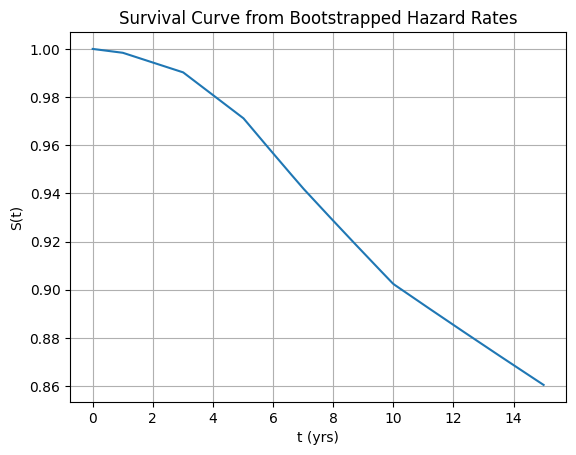

In [5]:
# Plot survival curve
ts = np.linspace(0.0, 15.0, 300)
Ss = [survival_curve(t) for t in ts] 
plt.plot(ts, Ss, label='Survival Probability S(t)')
plt.xlabel('t (yrs)')
plt.ylabel('S(t)')
plt.title('Survival Curve from Bootstrapped Hazard Rates')
plt.grid()

Once the CDS is completed, we compute the calculation of the main blocks that constitute the estimation of the (continuous in underlying) CVA estimation: $p(t_i),\Delta  q(t_i), v[S(t_i), t_i]$: 

#### Discount factors $p(t_i)$ grid

In [6]:
p_t = discount_factors_on_grid(t, P0_func=P0_flat)
print(p_t)

[1.         0.99659839 0.99320835 0.98982985]


#### Default probabilities increments $\Delta q (t_i)$ grid

In [7]:
q_t = default_increments_on_grid(t, q_interval=q_interval)
print(q_t)

[0.         0.00027184 0.00027177 0.00027169]


Positive exposure $v[S(t_i)]^+$ grid

In [29]:
S_by_time = simulate_S(
    S0=S0, mu=mu, sigma=sigma, t=t, Z=Z,
    antithetic=True,
    moment_match=True,
    replications=100,
    replication_seed=12345,
    pathwise=True
)
print(f"S_by_time: list length = {len(S_by_time)}")
print(f"Each element shape = {S_by_time[0].shape}")

S_by_time: list length = 4
Each element shape = (20000000,)


In [30]:
# Vpos: (N_paths, M+1)
Vpos = positive_exposure_matrix_from_samples(S_by_time, t, K=K, r=r, T=T)
print("Vpos.shape:", Vpos.shape)

Vpos.shape: (20000000, 4)


---

### 2.1 Classical Benchmark using continuous underlying distribution

The CVA is estimated by Monte Carlo simulation using a time-discretized approximation of the continuous-time CVA integral. The underlying asset price is simulated under a lognormal dynamics, and exposures are evaluated on a finite time grid $\{t_i\}_{i=1}^M$.

At each time $t_i$, the simulated underlying price along path $k$ is
$$
S^{(k)}(t_i)
=
S_0 \exp\!\left((\mu - \tfrac{1}{2}\sigma^2)t_i + \sigma \sqrt{t_i}\,Z_i^{(k)}\right),
\qquad k=1,\dots,N.
$$

The corresponding positive exposure is
$$
[V^{(k)}(t_i)]^+
=
\max\!\left(S^{(k)}(t_i) - K\,P(t_i,T),\,0\right).
$$

Let
$$
q(t_{i-1},t_i) = S(t_{i-1}) - S(t_i)
$$
denote the default probability over the interval $(t_{i-1},t_i]$, obtained from the CDS bootstrap. For a fixed path $k$, the pathwise CVA contribution is
$$
\mathrm{CVA}^{(k)}
=
(1-R_{\mathrm{CVA}})
\sum_{i=1}^M
[V^{(k)}(t_i)]^+\,P(0,t_i)\,q(t_{i-1},t_i).
$$

The **Monte Carlo estimator of the CVA** is given by the sample mean over the $N$ simulated paths:
$$
\mathrm{CVA}_{MC}
=
\frac{1}{N}
\sum_{k=1}^N
\mathrm{CVA}^{(k)}
=
\frac{1-R_{\mathrm{CVA}}}{N}
\sum_{k=1}^N
\sum_{i=1}^M
[V^{(k)}(t_i)]^+\,P(0,t_i)\,q(t_{i-1},t_i).
$$

The **Monte Carlo error** associated with this estimator is quantified by its standard error. Let
$$
\sigma_{MC}^2
=
\frac{1}{N-1}
\sum_{k=1}^N
\left(\mathrm{CVA}^{(k)} - \mathrm{CVA}_{MC}\right)^2
$$
denote the sample variance of the pathwise CVA contributions. The standard error of the Monte Carlo estimator is then
$$
\mathrm{SE}\!\left(\mathrm{CVA}_{MC}\right)
=
\frac{\sigma_{MC}}{\sqrt{N}},
$$
which decreases at the canonical Monte Carlo rate $O(N^{-1/2})$.

We perform now the (continuous) estimation of CVA:

In [31]:
t0 = time.perf_counter()

# CVA & std error
CVA_MC, CVA_std_err_MC = cva_from_continuous_blocks(Vpos, p_t, q_t, LGD=LGD)

t1 = time.perf_counter()

print("Vpos:", Vpos.shape, "p_t:", p_t.shape, "q_t:", q_t.shape)
print("CVA:", CVA_MC, "SE:", CVA_std_err_MC)   
print(f"Elapsed time: {(t1 - t0):.6f} s")

Vpos: (20000000, 4) p_t: (4,) q_t: (4,)
CVA: 6.114841313934254e-05 SE: 2.8705509986604712e-08
Elapsed time: 0.257144 s


---

### 2.2 Classical Benchmark using discrete underlying distribution

In this section (replicating Sections 3 and 4.1 of Alcázar et al.) we address the classical estimation of the CVA by discretizing both the time dimension and the underlying asset price, with the aim of constructing a discrete joint distribution that will later serve as input for the quantum algorithm.

We consider a uniform time grid $\{t_i\}_{i=1}^M$ on the interval $[0,T]$. By construction, the marginal distribution of time is uniform and satisfies $P(t_i)=1/M$. At each time point $t_i$, the underlying asset price $S(t_i)$ is modeled as a geometric Brownian motion. A large number of independent samples of the marginal distribution of $S(t_i)$ are generated using classical Monte Carlo simulation. Since temporal correlations are not required at this stage, each marginal distribution $S(t_i)$ is simulated directly from the initial value $S_0$, which allows for an efficient estimation of the conditional density $P(s\mid t_i)$ at each time step.

The price space is discretized by introducing $N=2^n$ bins $\{s_j\}_{j=1}^N$. A global price range $[s_0,s_N]$ is defined using the sample mean and sample standard deviation of the asset price at maturity $T$. In particular, we set
$$
s_0 = \max\{\hat\mu_T - k\hat\sigma_T,\,0\}, \qquad
s_N = \hat\mu_T + k\hat\sigma_T,
$$
for a fixed constant $k=3$, and discretize this interval uniformly. For each time $t_i$, the conditional discrete distribution $P(s_j\mid t_i)$ is approximated by a normalized histogram over this price grid.

Under these assumptions, the joint discrete distribution of time and price is approximated as
$$
\mathcal{P}(s_j,t_i) = P(t_i)\,P(s_j\mid t_i) = \frac{1}{M} P(s_j\mid t_i),
$$
which ensures that the marginal distribution over time satisfies $P(t_i)=1/M$ exactly. This construction leads to the following approximation of the expected exposure at time $t_i$:
$$
\tilde{E}(t_i)
= \sum_{j=1}^N \frac{\mathcal{P}(s_j,t_i)}{P(t_i)}\, v(s_j,t_i)
= M \sum_{j=1}^N \mathcal{P}(s_j,t_i)\, v(s_j,t_i),
$$
where $v(s_j,t_i)$ denotes the positive payoff of the derivative evaluated at a representative price of the $j$-th bin.

Combining the discretizations in time and price, the resulting discrete approximation of the CVA is given by
$$
\mathrm{CVA}
= M(1-R)\sum_{i=1}^M \sum_{j=1}^N
\mathcal{P}(s_j,t_i)\, v(s_j,t_i)\, p(t_i)\, q(t_i),
$$
where $p(t_i)$ denotes the discount factor and $q(t_i)$ the incremental default probability over the interval $(t_{i-1},t_i]$.

In this section of the work, we implement this construction entirely on a classical computer: we simulate the marginal price distributions, discretize them on the chosen price grid, and evaluate the resulting discrete CVA. This classical implementation provides both a benchmark for comparison and a controlled setting to study the convergence of the CVA estimate as the number of price discretization levels $n$ increases.

In [14]:
n_sigma = 3.0

In [32]:
num_s = range(1, 15)
cva_by_n: dict[int, float] = {}

for n in num_s:
    edges, s_mid, P_s_t = grid_and_prob_matrix(S_by_time, n=n, n_sigma=n_sigma)
    v_s_t = payoff_matrix_forward_call(edges, t, K=K, r=r, T=T, payoff_repr="mid")
    cva_by_n[int(n)] = cva_discrete_from_blocks(P_s_t, v_s_t, p_t, q_t, LGD=LGD)

cva_by_n

{1: 0.00020304589859683573,
 2: 8.03343389498785e-05,
 3: 5.836338159019533e-05,
 4: 5.949469630638472e-05,
 5: 5.819976665310602e-05,
 6: 5.8334303662182504e-05,
 7: 5.8249246139393946e-05,
 8: 5.824623190032556e-05,
 9: 5.824113522175728e-05,
 10: 5.8240497103726385e-05,
 11: 5.824035031654846e-05,
 12: 5.824030180816533e-05,
 13: 5.824029966898529e-05,
 14: 5.8240296145475484e-05}

In [33]:
# =============================
# Proxy for CVA(\infty) 
# =============================

t_start = time.perf_counter()

n_inf = 20

# blocks -> CVA
edges, s_mid, P_s_t = grid_and_prob_matrix(S_by_time, n=n_inf, n_sigma=3.0)
v_s_t = payoff_matrix_forward_call(edges, t, K=K, r=r, T=T, payoff_repr="mid")

CVA_inf = cva_discrete_from_blocks(P_s_t, v_s_t, p_t, q_t, LGD=LGD)

t_end = time.perf_counter()
elapsed = t_end - t_start

print("CVA(inf) computation finished (1 run).")
print("CVA(inf) =", CVA_inf)
print("Elapsed time [s] =", elapsed)

CVA(inf) computation finished (1 run).
CVA(inf) = 5.824029647873356e-05
Elapsed time [s] = 49.946146199974464


In [34]:
# ==============================================================
# Discrete CVA results by discretization level n (1 run)
# ==============================================================

print("\nDISCRETE CVA ESTIMATES (per price discretization level) — 1 run")
print("--------------------------------------------------------------")

for n in num_s:
    cva_n = float(cva_by_n[n])
    print(
        f"n = {n:2d}   N = {2**n:5d} bins    "
        f"CVA = {cva_n:.10e}"
    )

print("--------------------------------------------------------------\n")

# ==============================================================
# Reference value: CVA(infinity) (1 run)
# ==============================================================

print("REFERENCE CVA (proxy for n → ∞) — 1 run")
print("--------------------------------------------------------------")
print(
    f"n_inf = {n_inf:2d}  |  "
    f"CVA(inf) = {float(CVA_inf):.10e}"
)

# ==============================================================
# Timing information
# ==============================================================

print("\nTotal execution time [s] =", elapsed)


DISCRETE CVA ESTIMATES (per price discretization level) — 1 run
--------------------------------------------------------------
n =  1   N =     2 bins    CVA = 2.0304589860e-04
n =  2   N =     4 bins    CVA = 8.0334338950e-05
n =  3   N =     8 bins    CVA = 5.8363381590e-05
n =  4   N =    16 bins    CVA = 5.9494696306e-05
n =  5   N =    32 bins    CVA = 5.8199766653e-05
n =  6   N =    64 bins    CVA = 5.8334303662e-05
n =  7   N =   128 bins    CVA = 5.8249246139e-05
n =  8   N =   256 bins    CVA = 5.8246231900e-05
n =  9   N =   512 bins    CVA = 5.8241135222e-05
n = 10   N =  1024 bins    CVA = 5.8240497104e-05
n = 11   N =  2048 bins    CVA = 5.8240350317e-05
n = 12   N =  4096 bins    CVA = 5.8240301808e-05
n = 13   N =  8192 bins    CVA = 5.8240299669e-05
n = 14   N = 16384 bins    CVA = 5.8240296145e-05
--------------------------------------------------------------

REFERENCE CVA (proxy for n → ∞) — 1 run
--------------------------------------------------------------
n_inf

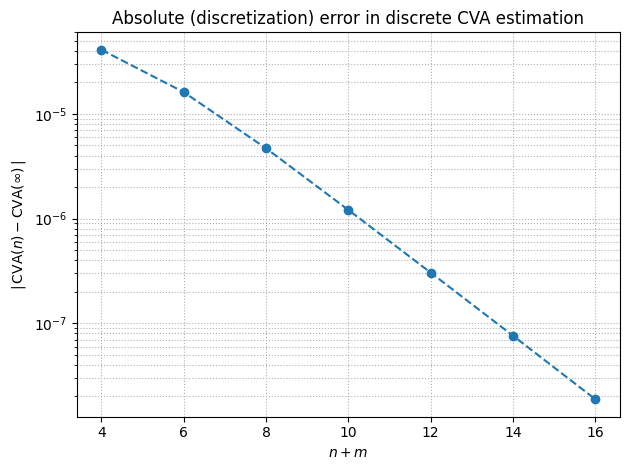

In [ ]:
m = int(np.log2(M))
ns_even = np.arange(2, 16, 2)  # n = 2,4,...,14

CVA_disc = np.array([float(cva_by_n[int(n)]) for n in ns_even], dtype=float)

cva_inf = float(CVA_inf)
abs_err = np.abs(CVA_disc - cva_inf)

x_vals = ns_even + m

plt.figure()
plt.plot(x_vals, abs_err, marker="o", linestyle="--")
plt.yscale("log")

plt.xlabel(r"$n+m$")
plt.ylabel(r"$|\,\mathrm{CVA}(n)-\mathrm{CVA}(\infty)\,|$")
plt.title("Absolute (discretization) error in discrete CVA estimation")
plt.grid(True, which="both", linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.show()

To evaluate how great the distorsion in the CVA estimation caused by price discretization is, we compute the relative error commited in the estimation with respect to the estimation via continuous underlying distribution:

In [22]:
rel_err = np.abs(CVA_inf - CVA_MC) / CVA_MC * 100
print(f"Relative error between continuous CVA and CVA(inf): {rel_err:.6f} %")

Relative error between continuous CVA and CVA(inf): 4.755345 %


To make this discrete formulation compatible with the quantum amplitude estimation framework, we introduce scaling constants $C_v$, $C_p$ and $C_q$ acting on the exposure payoff, discount factor and default probability, respectively. These constants are chosen such that the rescaled quantities $\tilde v = v / C_v$, $\tilde p = p / C_p$ and $\tilde q = q / C_q$ take values in the unit interval $[0,1]$, which is a necessary condition for their encoding into quantum amplitudes. The CVA is then estimated in terms of these normalized quantities and subsequently rescaled by the factor $C_v C_p C_q$ to recover the correct physical magnitude. Concretely, the resulting estimator reads
$$
\mathrm{CVA}
= M(1-R)\,C_v C_p C_q \sum_{i=1}^{M}\sum_{j=1}^{N}
\mathcal{P}(s_j,t_i)\,\tilde v(s_j,t_i)\,\tilde p(t_i)\,\tilde q(t_i),
$$
where $\tilde v(s_j,t_i)=v(s_j,t_i)/C_v$, $\tilde p(t_i)=p(t_i)/C_p$, and $\tilde q(t_i)=q(t_i)/C_q$.


We aim now to replicate the particular instance in page 9 of Alcázar et al., however, we need to calculate our scaling constants which in general will be different from those used in the paper. We'll calculate them setting $n=2$ underlying discretization bins:

In [49]:
n_use = 2

tab = extract_tables_and_scalings(
    S_by_time=S_by_time,
    t=t,
    K=K,
    r=r,
    T=T,
    p_t=p_t,         # ya precomputado en la malla completa t[0..M]
    q_t=q_t,         # ya precomputado en la malla completa t[0..M], con q_t[0]=0
    n=n_use,
    n_sigma=3.0,
    payoff_repr="mid",
)

C_v, C_p, C_q = tab.C_v, tab.C_p, tab.C_q
print("\nSCALING CONSTANTS USED:")
print(f"C_v = {C_v:.6f}")
print(f"C_p = {C_p:.6f}")
print(f"C_q = {C_q:.6f}\n")


SCALING CONSTANTS USED:
C_v = 1.654738
C_p = 1.000001
C_q = 0.000272



With this scaling constants we now check the results obtained using the scaled (quantum-ready) version of the CVA estimation outputs the same result as in the previous section, for $n=2$:

In [24]:
tab = extract_tables_and_scalings(
    S_by_time=S_by_time,
    t=t,
    K=K,
    r=r,
    T=T,
    p_t=p_t,
    q_t=q_t,
    n=n_use,
    n_sigma=3.0,
    payoff_repr="right",
)

# scaled CVA (uses C_v,C_p,C_q)
scaled_CVA = cva_discrete_from_blocks(
    tab.P_s_t,
    tab.v_s_t,
    tab.p_t,
    tab.q_t,
    LGD=LGD,
    C_v=tab.C_v,
    C_p=tab.C_p,
    C_q=tab.C_q,
)

# unscaled CVA (same blocks, but constants = 1)
unscaled_CVA = cva_discrete_from_blocks(
    tab.P_s_t,
    tab.v_s_t,
    tab.p_t,
    tab.q_t,
    LGD=LGD,
    C_v=1.0,
    C_p=1.0,
    C_q=1.0,
)

print(f"CVA scaled   (n={n_use}) =", scaled_CVA)
print(f"CVA unscaled (n={n_use}) =", unscaled_CVA)

CVA scaled   (n=2) = 0.0002285519001153156
CVA unscaled (n=2) = 0.0002285519001153156


Getting the same result as expected. Now, we compute the (relative) discretization error (probability lost when considering n=2):

In [38]:
rel_discretization_error = abs(scaled_CVA - CVA_MC) / CVA_MC * 100.0
print(
    "Relative discretization error (discretized underlying CVA (n=2) vs continuous CVA): "
    f"{rel_discretization_error:.6f} %"
)

Relative discretization error (discretized underlying CVA (n=2) vs continuous CVA): 71.697439 %


The relatively large error (≈37%) observed for \(n=2\) is expected, as such a coarse price discretization leads to a significant loss of probability mass in the tails of the underlying distribution, resulting in a biased CVA estimate. This effect is consistent with Alcázar et al., who also report large discretization errors for small \(n\), primarily driven by truncation of the price domain and the associated loss of tail probabilities.

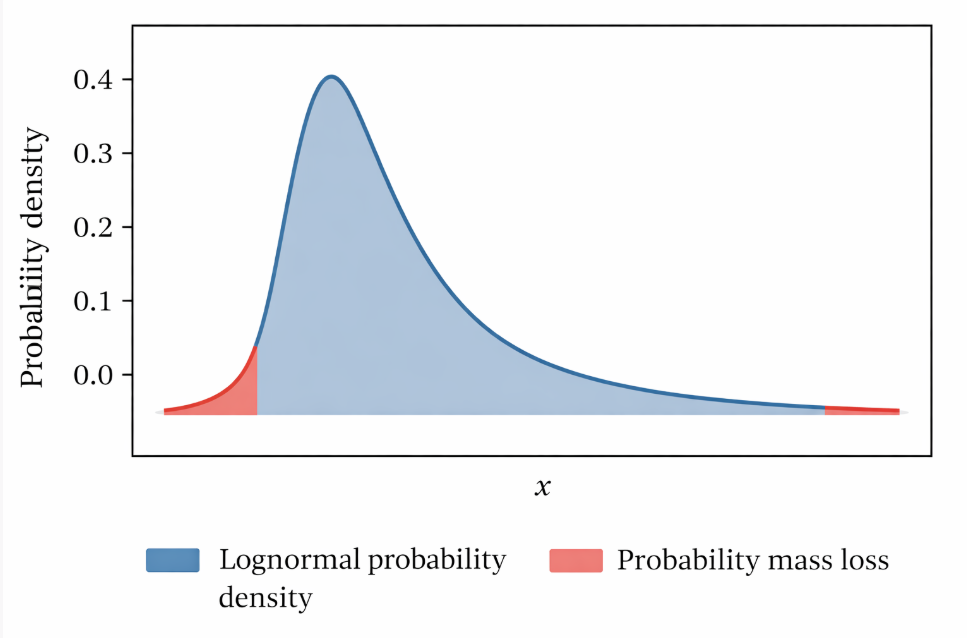

---